In [1]:
import numpy as np
import os, glob
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import json
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.glm.first_level import FirstLevelModel
from scipy import stats


In [2]:
#These are some runs we will consider for processing.
#Be sure that the events.tsv files are correct for all the runs that are entered here.
to_proc_initial = {
            "sub-NU001" : ["run-01", "run-02"],
            "sub-NU005" : ["run-01", "run-02"],
            "sub-NU007" : ["run-01", "run-02"],
            "sub-NU008" : ["run-01", "run-02"],
            "sub-NU010" : ["run-01", "run-02"],
            "sub-NU011" : ["run-01", "run-02"],
            "sub-NU013" : ["run-01", "run-02"],
            "sub-NU014" : ["run-01", "run-02"],
            "sub-NU015" : ["run-01", "run-02"],
            "sub-NU016" : ["run-01", "run-02"],
            "sub-NU018" : ["run-01", "run-02"],
            "sub-NU019" : ["run-01", "run-02"],
            "sub-NU024" : ["run-01"],
        }

In this next section of code we will be sure that each run has the Positive, Negative,and Neutral trials before considering them for processing.
Also we will pre-populate some arrays to store outputs of interest (run_level_zscores, etc.)

In [3]:
to_proc_final = {}

#This is a standalong directory where all the events.tsv files are stored.
#For the subjects initially put into "to_proc", the timing has been vetted to be
#sure the task logs start around the same time as the fMRI acquisition
events_tsv_top_dir = '/projects/standard/lewi1538/shared/projects/neg_urg/events_tsvs_2'

#The tip directory with fMRIPREP outputs
fmriprep_top_dir = '/projects/standard/lewi1538/shared/projects/neg_urg/derivatives/fmriprep/'

trials_types_of_interest = ["Positive", "Negative", "Neutral", "RestList", "BlockList", "Neutral", "Prep", "AllGo", "Scrambled"]
num_total_vols = 0
print('Currently requiring all runs to have positive, negative, and neutral block\n')
for temp_subject in to_proc_initial.keys():
    temp_runs = []
    for temp_run in to_proc_initial[temp_subject]:
        
        session = 'ses-1'
        timing_file = os.path.join(events_tsv_top_dir, temp_subject, session, 'func', '{}_{}_task-taskMENORDIC_{}_events.tsv'.format(temp_subject, session, temp_run))
        timing_df = pd.read_csv(timing_file, delimiter='\t')
        timing_subset_df = timing_df[timing_df['trial_type'].isin(trials_types_of_interest)]
        
        if np.sum(timing_subset_df['trial_type'] == 'Positive')*np.sum(timing_subset_df['trial_type'] == 'Negative')*np.sum(timing_subset_df['trial_type'] == 'Neutral'):
            num_total_vols += 1
            temp_runs.append(temp_run)
            to_proc_final[temp_subject] = temp_runs
        else:
            print('Skipping {} and {} because contrast isnt available'.format(temp_subject, temp_run))
            
            
#The output array to store z-scores from the task
run_level_zscores = np.zeros((num_total_vols, 91, 109, 91))
run_level_stats = np.zeros((num_total_vols, 91, 109, 91))
run_level_effect_sizes = np.zeros((num_total_vols, 91, 109, 91))

Currently requiring all runs to have positive, negative, and neutral block

Skipping sub-NU001 and run-02 because contrast isnt available
Skipping sub-NU007 and run-02 because contrast isnt available
Skipping sub-NU011 and run-01 because contrast isnt available
Skipping sub-NU011 and run-02 because contrast isnt available
Skipping sub-NU013 and run-01 because contrast isnt available
Skipping sub-NU024 and run-01 because contrast isnt available


In [4]:
run_level_zscores.shape

(19, 91, 109, 91)

In [5]:
skipped_runs = {}
for temp_subject in to_proc_initial.keys():
    if temp_subject not in to_proc_final.keys():
        skipped_runs[temp_subject] = to_proc_initial[temp_subject]
        continue
    temp_arr = []
    for temp_run in to_proc_initial[temp_subject]:
        if temp_run not in to_proc_final[temp_subject]:
            temp_arr.append(temp_run)
            skipped_runs[temp_subject] = temp_arr
            
skipped_runs_conditions = {}           
for temp_subject in skipped_runs:
    skipped_runs_conditions[temp_subject] = []
    for temp_run in skipped_runs[temp_subject]:
        run_dict = {}
        timing_file = os.path.join(events_tsv_top_dir, temp_subject, session, 'func', '{}_{}_task-taskMENORDIC_{}_events.tsv'.format(temp_subject, session, temp_run))
        timing_df = pd.read_csv(timing_file, delimiter='\t')
        run_dict[temp_run] = timing_df['trial_type'].values.tolist()
        skipped_runs_conditions[temp_subject].append(run_dict)
        

In [6]:
#For simple analysis, iterate across all subjects and runs,
#running the fMRI analysis at each run.


################################################################################################################################
################################################################################################################################
###Parameters that can easily be changed to modify analyses
################################################################################################################################

#All trial types. Currently all trials listed below will be modeled in the GLM
trials_types_of_interest = ["Positive", "Negative", "Neutral", "RestList", "BlockList", "Neutral", "Prep", "AllGo", "Scrambled"]

#smoothing kernel in volume space
smooth_fwhm_mm = 4

#hrf model (for other options see nilearn documentation)
hrf_model = "glover + derivative"

#the contrast of interest. Terms must be derived from conditions listed under trials_types_of_interest
contrast_id = ['Neutral - Negative']

#these are columns that will be taken from the confounds.tsv that is produced by fmriprep. any column can
#be included as long as it is found for all subjects. Other regressors include things like motion realignment paramaters,
#wm/csf signals, etc.
confound_columns = ['global_signal']

#The number of terms for the polynomial drift
drift_order = 2

#Currently the settings don't have an option for scrubbing, but that could be added as well.

################################################################################################################################
################################################################################################################################
################################################################################################################################

#The task modeling being used is simple. 
i = -1
for temp_subject in to_proc_final.keys():
    for temp_run in to_proc_final[temp_subject]:
        
        print('{} {}'.format(temp_subject, temp_run))            
        i += 1
        subject = temp_subject
        session = 'ses-1' #We assume this is the same for all subjects
        run_number = temp_run

        #Load the events.tsv
        timing_file = os.path.join(events_tsv_top_dir, subject, session, 'func', '{}_{}_task-taskMENORDIC_{}_events.tsv'.format(subject, session, run_number))
        timing_df = pd.read_csv(timing_file, delimiter='\t')

        #Load the minimally pre-processed fMRI acquisition in MNI space
        nifti_file = os.path.join(fmriprep_top_dir, '{}'.format(subject), subject, session, 'func', '{}_{}_task-taskMENORDIC_{}_space-MNI152NLin6Asym_res-2_desc-preproc_bold.nii.gz'.format(subject, session, run_number))
        nifti_img = nib.load(nifti_file)
        nifti_vols = nifti_img.shape[-1]
        fmri_img = nib.load(nifti_file)
        
        #Find the TR
        json_file = nifti_file.replace('.nii.gz', '.json')
        with open(json_file, 'r') as f:
            content = json.load(f)
        TR = content['RepetitionTime']

        #Load the confounds file
        confounds_path = os.path.join(fmriprep_top_dir, subject, subject, session, 'func', '{}_{}_task-taskMENORDIC_{}_desc-confounds_timeseries.tsv'.format(subject, session, run_number))
        confounds_df = pd.read_csv(confounds_path, delimiter='\t')

        
        #Load a GM mask and threshold it at 0.5 probability
        #Note - the mask doesnt get used in the smoothing, only the GLM
        mask_paths = glob.glob(os.path.join(fmriprep_top_dir, subject, subject, session, 'anat', '{}_{}_run-*_space-MNI152NLin6Asym_res-2_label-GM_probseg.nii.gz'.format(subject, session)))
        if len(mask_paths) != 1:
            raise ValueError('Error')
        else:
            mask_path = mask_paths[0]
        mask_img = nib.load(mask_path)
        thresholded_mask_img = nib.nifti1.Nifti1Image(mask_img.get_fdata() > 0.5, mask_img.affine, mask_img.header)


        ############################################################
        ############################################################

        #Create a dataframe using the trials that have been mentioned in the trials_types_of_interest
        timing_subset_df = timing_df[timing_df['trial_type'].isin(trials_types_of_interest)]
        
        #Create a dataframe using the confounds listed in confound_columns
        task_confound_df = confounds_df[confound_columns]

        #Create an array to represent time
        times = np.linspace(0, (nifti_vols - 1)*TR, nifti_vols)
        
        #Create a design matrix for modeling using the inputs described above. See nilearn for details on make_first_level_design_matrix.
        X1 = make_first_level_design_matrix(
            times,
            timing_subset_df,
            drift_model="polynomial",
            drift_order=drift_order,
            add_regs=task_confound_df,
            hrf_model=hrf_model,
        )

        #Initialize and fit the GLM
        fmri_glm = FirstLevelModel(mask_img=thresholded_mask_img, smoothing_fwhm=smooth_fwhm_mm, standardize=False)
        fmri_glm = fmri_glm.fit(fmri_img, design_matrices=X1)

        #Compute the contrast
        results = fmri_glm.compute_contrast(contrast_id, output_type="all")
        
        #Save the results out to an output array. In the output array there will be one entry per run,
        #so some subjects will have 1 or 2 entries depending on the data that was collected.
        run_level_zscores[i,:,:,:] = results['z_score'].get_fdata()[:]
        run_level_stats[i,:,:,:] = results['stat'].get_fdata()[:]
        run_level_effect_sizes[i,:,:,:] = results['effect_size'].get_fdata()[:]

sub-NU001 run-01
sub-NU005 run-01


/tmp/ipykernel_2082688/1883501025.py:106: UserWarning: t contrasts should be of length P=20, but it has length 18. The rest of the contrast was padded with zeros.
  results = fmri_glm.compute_contrast(contrast_id, output_type="all")


sub-NU005 run-02
sub-NU007 run-01


/tmp/ipykernel_2082688/1883501025.py:106: UserWarning: t contrasts should be of length P=20, but it has length 18. The rest of the contrast was padded with zeros.
  results = fmri_glm.compute_contrast(contrast_id, output_type="all")


sub-NU008 run-01


...

/tmp/ipykernel_2082688/1883501025.py:106: UserWarning: t contrasts should be of length P=20, but it has length 18. The rest of the contrast was padded with zeros.
  results = fmri_glm.compute_contrast(contrast_id, output_type="all")


sub-NU019 run-01


/tmp/ipykernel_2082688/1883501025.py:106: UserWarning: t contrasts should be of length P=20, but it has length 18. The rest of the contrast was padded with zeros.
  results = fmri_glm.compute_contrast(contrast_id, output_type="all")


sub-NU019 run-02


/tmp/ipykernel_2082688/1883501025.py:106: UserWarning: t contrasts should be of length P=20, but it has length 18. The rest of the contrast was padded with zeros.
  results = fmri_glm.compute_contrast(contrast_id, output_type="all")


### Calculate summary stats and visualize them

This is very simplified and assumes the different runs are i.i.d. even though some
runs are from the same subject.

(array([0.0000e+00, 0.0000e+00, 4.4000e+01, 6.7640e+03, 7.1812e+04,
        7.3748e+04, 7.3330e+03, 2.7000e+01, 0.0000e+00, 0.0000e+00]),
 array([-8. , -6.4, -4.8, -3.2, -1.6,  0. ,  1.6,  3.2,  4.8,  6.4,  8. ]),
 <BarContainer object of 10 artists>)

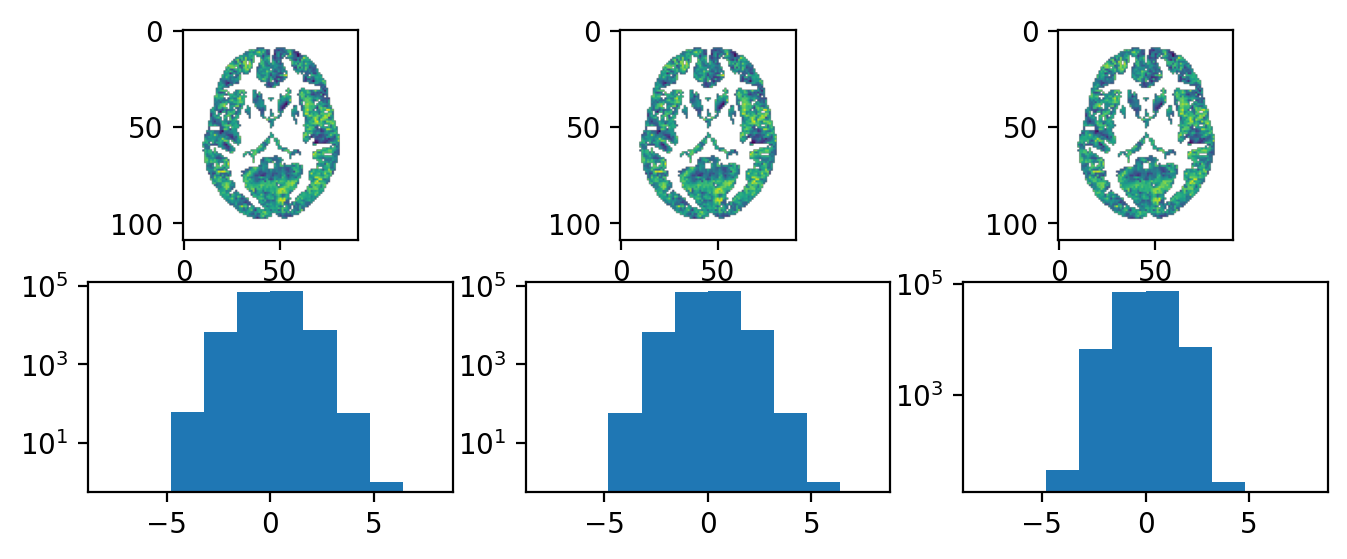

In [8]:
run_combined_zscore_tstats = stats.ttest_1samp(run_level_zscores, popmean=0, axis=0)
run_combined_stats_tstats = stats.ttest_1samp(run_level_stats, popmean=0, axis=0)
run_combined_effect_sizes_tstats = stats.ttest_1samp(run_level_effect_sizes, popmean=0, axis=0)

plt.figure(dpi=200, figsize=(8,3))
plt.subplot(2,3,1)
plt.imshow(np.rot90(run_combined_zscore_tstats.statistic[:,:,40].squeeze()), vmin=-3, vmax=3)
plt.subplot(2,3,2)
plt.imshow(np.rot90(run_combined_stats_tstats.statistic[:,:,40].squeeze()), vmin=-3, vmax=3)
plt.subplot(2,3,3)
plt.imshow(np.rot90(run_combined_effect_sizes_tstats.statistic[:,:,40].squeeze()), vmin=-3, vmax=3)
plt.subplot(2,3,4)
plt.hist(run_combined_zscore_tstats.statistic.flatten(), range=(-8,8), log=True)
plt.subplot(2,3,5)
plt.hist(run_combined_stats_tstats.statistic.flatten(), range=(-8,8), log=True)
plt.subplot(2,3,6)
plt.hist(run_combined_effect_sizes_tstats.statistic.flatten(), range=(-8,8), log=True)

In [22]:
raise NameError('Pausing - remove this error statement if you want to save new file.')
results_img = nib.nifti1.Nifti1Image(run_combined_zscore_tstats.statistic, mask_img.affine, mask_img.header)
nib.save(results_img, '/projects/standard/lewi1538/shared/projects/leex6144_neg_urg/test/example_output_neutral_minus_negative_simple_groupttest.nii.gz')